# Phase 4 — Predictive & Prescriptive Modeling

**Sub-question #6:** *Can we predict a low-review order (≤ 3) before the review arrives?*
**Sub-question #7:** *Which orders should ops proactively intervene on?*

**Target:** `low_review = 1 if review_score <= 3 else 0`. A Logistic Regression baseline is compared against a tuned LightGBM; SHAP explains the winner; the predicted probability then drives a prescriptive intervention simulation. Shared feature logic is imported from `src/features.py`. (Phase 5's findings section will be appended to the end of this notebook.)

## Setup & features

`build_feature_matrix` (in `src/features.py`) drops null-review orders and derives `actual_delivery_days`, `freight_ratio`, `purchase_weekday`, and the target. Feature set: delivery gap, actual delivery days, total payment value, total freight, freight ratio, primary category, customer state, payment type, max installments, item count, purchase weekday.

In [1]:
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve)

if Path.cwd().name == "notebooks":
    os.chdir("..")
REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))
from src.features import build_feature_matrix, time_split, NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET

FIG_DIR = REPO_ROOT / "reports" / "figures"
OUT_DIR = REPO_ROOT / "outputs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
RANDOM_STATE = 7

def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")
    print(f"saved -> reports/figures/{name}.png")

In [2]:
orders = duckdb.sql("SELECT order_id, review_score, order_purchase_timestamp, order_delivered_customer_date, "
                    "total_price, total_freight, total_payment_value, max_installments, item_count, "
                    "payment_type, primary_category, customer_state, delivery_gap_days "
                    "FROM 'data/processed/orders_clean.parquet'").df()
features = build_feature_matrix(orders)
print(f"feature matrix: {features.shape[0]:,} orders x {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)} features")
print(f"positive rate (low_review): {features[TARGET].mean():.3f}")

feature matrix: 95,824 orders x 11 features
positive rate (low_review): 0.211


## Train/test split — time-based, not random

**Split at 2018-06-01:** train on orders purchased before, test on orders after (~19% of data). A **random** split would leak the future into the past — the model would train on orders that occurred *after* some test orders, which is impossible in production where we score an order the moment it is placed/delivered and only past data exists. A time split reproduces that constraint and gives an honest estimate of live performance.

In [3]:
train, test = time_split(features, "2018-06-01")
X_tr, y_tr = train[NUMERIC_FEATURES + CATEGORICAL_FEATURES], train[TARGET]
X_te, y_te = test[NUMERIC_FEATURES + CATEGORICAL_FEATURES], test[TARGET]
print(f"train: {len(train):,} orders ({y_tr.mean():.3f} positive)   "
      f"test: {len(test):,} orders ({y_te.mean():.3f} positive)")

train: 77,304 orders (0.221 positive)   test: 18,520 orders (0.166 positive)


**Timing caveat (honest framing).** `delivery_gap_days` and `actual_delivery_days` are only known *after* delivery completes. This model is therefore an **at-delivery** risk score — computed the moment an order is delivered, *before* the customer submits a review — not an at-purchase one. That is still actionable: the prescriptive intervention below is proactive outreach in the post-delivery / pre-review window. Features are not weighted for class imbalance; we evaluate with threshold-independent metrics (ROC-AUC, PR-AUC) and set the real operating point in the prescriptive section.

## Base model — Logistic Regression

Standardized numeric features + one-hot categoricals (median imputation for the single null-value order). Reported at the default 0.5 threshold plus threshold-independent AUCs.

In [4]:
def score_model(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
    }

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])
logit = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=2000))]).fit(X_tr, y_tr)
proba_logit = logit.predict_proba(X_te)[:, 1]
m_logit = score_model(y_te, proba_logit)
print({k: round(v, 3) for k, v in m_logit.items()})

{'Accuracy': 0.837, 'Precision': 0.595, 'Recall': 0.049, 'F1': 0.09, 'ROC-AUC': 0.639, 'PR-AUC': 0.302}


## Improved model — LightGBM (5-fold tuned)

LightGBM with native categorical handling and **5-fold stratified** grid search over `learning_rate`, `num_leaves`, `min_child_samples` (scored on ROC-AUC).

In [5]:
X_tr_lgb, X_te_lgb = X_tr.copy(), X_te.copy()
for col in CATEGORICAL_FEATURES:
    X_tr_lgb[col] = X_tr_lgb[col].astype("category")
    X_te_lgb[col] = pd.Categorical(X_te_lgb[col], categories=X_tr_lgb[col].cat.categories)

grid = {"learning_rate": [0.05, 0.1], "num_leaves": [31, 63], "min_child_samples": [20, 50]}
search = GridSearchCV(
    lgb.LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, verbose=-1),
    grid, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc", n_jobs=-1,
).fit(X_tr_lgb, y_tr)

best_lgb = search.best_estimator_
proba_lgb = best_lgb.predict_proba(X_te_lgb)[:, 1]
m_lgb = score_model(y_te, proba_lgb)
print("best params:", search.best_params_)
print({k: round(v, 3) for k, v in m_lgb.items()})

best params: {'learning_rate': 0.05, 'min_child_samples': 20, 'num_leaves': 31}
{'Accuracy': 0.844, 'Precision': 0.68, 'Recall': 0.114, 'F1': 0.195, 'ROC-AUC': 0.657, 'PR-AUC': 0.355}


## Model comparison

Side-by-side metrics, confusion matrices, and ROC / PR curves.

           Logistic Regression  LightGBM
Accuracy                 0.837     0.844
Precision                0.595     0.680
Recall                   0.049     0.114
F1                       0.090     0.195
ROC-AUC                  0.639     0.657
PR-AUC                   0.302     0.355


saved -> reports/figures/05_confusion_matrices.png


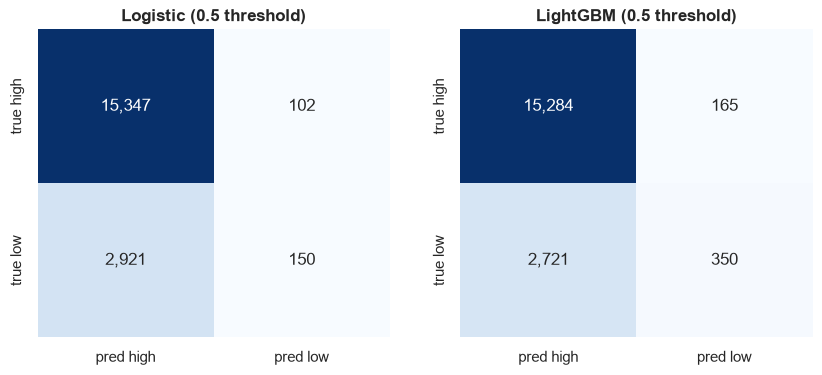

saved -> reports/figures/05_roc_pr_curves.png


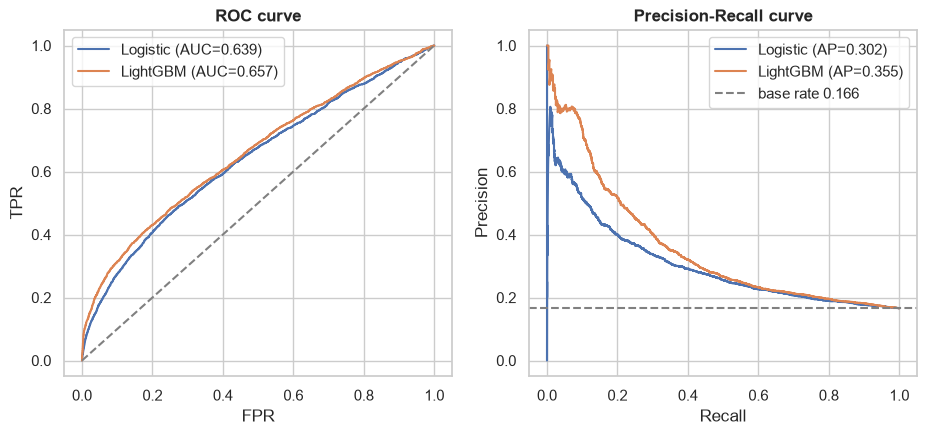

In [6]:
comparison = pd.DataFrame({"Logistic Regression": m_logit, "LightGBM": m_lgb}).round(3)
print(comparison.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, proba) in zip(axes, [("Logistic", proba_logit), ("LightGBM", proba_lgb)]):
    cm = confusion_matrix(y_te, (proba >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred high", "pred low"], yticklabels=["true high", "true low"])
    ax.set_title(f"{name} (0.5 threshold)")
save_fig(fig, "05_confusion_matrices")
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
for name, proba in [("Logistic", proba_logit), ("LightGBM", proba_lgb)]:
    fpr, tpr, _ = roc_curve(y_te, proba)
    ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_te, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_te, proba)
    ax2.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_te, proba):.3f})")
ax1.plot([0, 1], [0, 1], "--", color="grey"); ax1.set_title("ROC curve"); ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR"); ax1.legend()
ax2.axhline(y_te.mean(), ls="--", color="grey", label=f"base rate {y_te.mean():.3f}")
ax2.set_title("Precision-Recall curve"); ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision"); ax2.legend()
save_fig(fig, "05_roc_pr_curves")
plt.show()

**Takeaway.** LightGBM beats the linear baseline on every threshold-independent metric (ROC-AUC 0.66 vs 0.64, PR-AUC 0.36 vs 0.30) and recovers far more true low-reviews at the 0.5 threshold. Both AUCs are **modest** — an honest reflection that a 1–5 review is driven partly by factors we cannot observe (product expectations, customer mood). The value is not a perfect classifier but a **useful risk ranking**, which the prescriptive section exploits.

## Explainability — SHAP

SHAP values on a test sample explain the LightGBM model's drivers. The check that matters: **do SHAP's top features match the inferential tests?** (delivery gap and category should lead; freight ratio and installments should trail.)

Top-5 features by mean |SHAP|:
delivery_gap_days       0.2614
actual_delivery_days    0.2461
item_count              0.1770
primary_category        0.1426
customer_state          0.0666


saved -> reports/figures/05_shap_summary.png


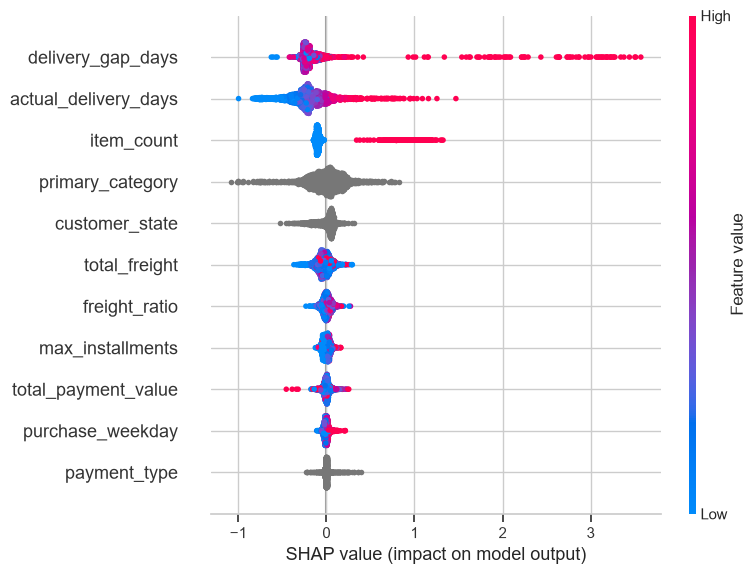

In [7]:
sample = X_te_lgb.sample(min(2500, len(X_te_lgb)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(sample)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=sample.columns).sort_values(ascending=False)
print("Top-5 features by mean |SHAP|:")
print(mean_abs.head(5).round(4).to_string())

fig = plt.figure()
shap.summary_plot(shap_values, sample, show=False, max_display=11)
save_fig(plt.gcf(), "05_shap_summary")
plt.show()

**SHAP vs inferential agreement.** Delivery timing dominates — `delivery_gap_days` and `actual_delivery_days` are the top two drivers by a wide margin — with `primary_category` (#4) and `customer_state` (#5) close behind, exactly the effects the Welch t-test and ANOVA flagged as significant. At the bottom sit `freight_ratio` (#7), `max_installments` (#8) and `payment_type` (last), matching their weak/small inferential effects — notably the added `payment_type` feature earns almost nothing. The one high-ranking feature the formal tests didn't cover is `item_count` (#3): larger multi-item orders carry more that can go wrong (more sellers, more parcels, more failure points). Two independent methods agreeing on the driver ranking is a strong credibility signal.

## Why the improved model wins — a nonlinear effect

A SHAP dependence plot for `delivery_gap_days`. If the relationship were linear, logistic would capture it; a kink shows why the tree model adds value.

saved -> reports/figures/05_shap_dependence_delivery_gap.png


<Figure size 640x480 with 0 Axes>

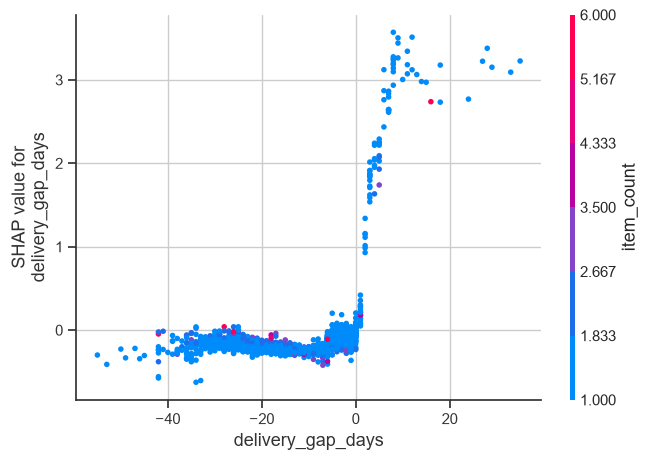

In [8]:
fig = plt.figure()
shap.dependence_plot("delivery_gap_days", shap_values, sample, show=False)
save_fig(plt.gcf(), "05_shap_dependence_delivery_gap")
plt.show()

**Interaction takeaway.** The SHAP value of `delivery_gap_days` is **flat and slightly protective while the order runs early (gap < 0), then rises sharply once the gap crosses zero (late)** — a hinge, not a straight line. Customers barely reward *extra* earliness but punish lateness steeply, and the effect is amplified for certain categories/routes (the dependence colouring). Logistic regression, being linear in the feature, cannot represent this kink — which is why LightGBM's AUC is higher.

## Prescriptive — who to intervene on

Use the LightGBM probability as a **risk score** and flag the **top-decile** riskiest orders. Simulate: how many low reviews are caught, at what flagged volume and precision, and — under an explicit assumption — the marketplace review-score lift.

In [9]:
risk = proba_lgb
threshold = np.quantile(risk, 0.90)
flagged = risk >= threshold

n_flagged = int(flagged.sum())
caught = int(y_te[flagged].sum())
precision_at = y_te[flagged].mean()
recall_at = caught / y_te.sum()
base_rate = y_te.mean()

print(f"top-decile risk threshold: {threshold:.3f}")
print(f"orders flagged:            {n_flagged:,} of {len(y_te):,} ({n_flagged/len(y_te):.1%})")
print(f"low reviews caught:        {caught:,} of {int(y_te.sum()):,} ({recall_at:.1%} recall)")
print(f"precision in flagged set:  {precision_at:.3f}  vs base rate {base_rate:.3f}  ({precision_at/base_rate:.1f}x lift)")

# Review-lift simulation. ASSUMPTION: proactive outreach prevents 30% of the low reviews
# it catches, and a prevented low review would instead have landed at 4 stars.
PREVENT_FRACTION = 0.30
BUMPED_SCORE = 4.0
test_scores = orders.set_index("order_id").loc[test["order_id"], "review_score"].values
flagged_low_mask = flagged & (y_te.values == 1)
prevented = int(round(flagged_low_mask.sum() * PREVENT_FRACTION))

new_scores = test_scores.copy()
prevent_idx = np.where(flagged_low_mask)[0][:prevented]
new_scores[prevent_idx] = BUMPED_SCORE
lift = new_scores.mean() - test_scores.mean()
print(f"\nassumption: prevent {PREVENT_FRACTION:.0%} of caught low reviews -> {prevented:,} orders bumped to {BUMPED_SCORE:.0f} stars")
print(f"test-set avg review: {test_scores.mean():.4f} -> {new_scores.mean():.4f}  (lift +{lift:.4f} stars)")
print("NOTE: this is a simulation under a stated assumption, not a guaranteed outcome.")

top-decile risk threshold: 0.286
orders flagged:            1,852 of 18,520 (10.0%)
low reviews caught:        812 of 3,071 (26.4% recall)
precision in flagged set:  0.438  vs base rate 0.166  (2.6x lift)

assumption: prevent 30% of caught low reviews -> 244 orders bumped to 4 stars
test-set avg review: 4.3117 -> 4.3430  (lift +0.0313 stars)
NOTE: this is a simulation under a stated assumption, not a guaranteed outcome.


In [10]:
risk_scores = test[["order_id", "order_purchase_timestamp", TARGET]].copy()
risk_scores["risk_score"] = risk
risk_scores["flagged_top_decile"] = flagged
risk_scores.to_parquet(OUT_DIR / "model_risk_scores.parquet", index=False)
print(f"saved {len(risk_scores):,} order-level risk scores -> outputs/model_risk_scores.parquet")

saved 18,520 order-level risk scores -> outputs/model_risk_scores.parquet


**Prescriptive takeaway.** Flagging the **top-decile** riskiest orders (~1.9k orders, 10% of volume) surfaces a set that is **~2.6×** more likely to be low-review than average (precision ~0.44 vs 0.17 base rate) and captures ~26% of all low reviews. Under the stated assumption (prevent 30% of caught low reviews, converting them to 4 stars), the simulated marketplace review lift is small in absolute terms — because low reviews are a minority — but it concentrates ops effort on the orders where a save is most likely, rather than spreading outreach across all orders.

**Handoff to Phase 5.** The finding chain is complete: EDA sized the problem (R$2.97M at risk), the inferential tests confirmed delivery gap / category / state variance as significant drivers, and this model both ranks orders by risk and confirms (via SHAP) that delivery and category dominate — giving concrete, evidence-backed recommendations to write up.